In [1]:
# !pip install anomalib
# !pip install matplotlib
# !pip install numpy
# !pip install tensorboard
# !pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
# !pip install kaggle


In [2]:
import copy
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
from torch.optim.lr_scheduler import MultiStepLR

from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

from anomalib.metrics.aupro import _AUPRO as DirectAUPRO
from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel

# import warnings
# warnings.filterwarnings('ignore')

c:\Users\AERO\Desktop\master_work\Experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# CUDA/kernel guard. Run before training to make sure this notebook uses my_env with CUDA PyTorch.
import sys
import torch

print("Python executable:", sys.executable)
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

assert "+cu128" in torch.__version__, "Expected CUDA 12.8 PyTorch wheel, e.g. torch==2.7.1+cu128"
assert torch.cuda.is_available(), "CUDA is not visible from this notebook kernel"


Python executable: c:\Users\AERO\Desktop\master_work\Experiments\.venv\Scripts\python.exe
torch: 2.7.1+cu128
torch.version.cuda: 12.8
cuda available: True
cuda device: NVIDIA GeForce RTX 3070 Ti Laptop GPU


# SuperSimpleNet MVTec: fixed unsupervised proxy comparison

This notebook is based on `SuperSimpleNet_mvtec.ipynb` and keeps the same SSN training path.
It tests Experiment C from `plans.md`: can fixed synthetic validation/test metrics act as a proxy when real test masks/labels are unavailable?

Datasets used by the run:

- 1 train dataset: normal `train/good` images only;
- 4 validation datasets: fixed synthetic segmentation, fixed synthetic classification, real segmentation reference, real classification reference;
- 4 test datasets: fixed synthetic segmentation, fixed synthetic classification, real segmentation reference, real classification reference.

Real labels/masks are used only for reference metrics and visual comparison. Synthetic reference datasets are generated once before training and then reused.

Important SSN detail from `ssn_calculator.ipynb`: synthetic anomalies are produced in the training path by `downsample_mask -> anomaly_generator -> segdec`. Here the reference dataset fixes the generated masks/labels once, then reuses those masks with the current model during validation/test.

# Senior ML review notes

Вопросы к исходному ноутбуку и итоговая валидация:

1. `predict_with_augmentations` назывался TTA, но фактически использовал только исходное изображение, а flip-код был закомментирован. Это не баг в метрике, но источник путаницы. Меняю на `predict_anomaly_map`, где явно видно: один forward, `sigmoid` для pixel logits, optional resize.
2. `torch.sigmoid(output.anomaly_map)` выглядит подозрительно только на первый взгляд. Для SSN segmentation decoder обычно возвращает logits, а `SSNLoss` обучает карту как logits against target mask. Для визуализации и pixel metrics нужна probability-like карта, поэтому sigmoid оставляем, но делаем это в одной функции и не смешиваем с `+ 1` или TTA.
3. Странная карта на normal image частично объясняется визуализацией: matplotlib раньше авторастягивал colormap под min/max конкретной картинки. Даже слабый фон начинал выглядеть ярким. Теперь heatmap фиксируется в диапазоне `vmin=0, vmax=1`, а картинка денормализуется и clamp'ится.
4. Training loss path и validation loss path были реализованы разными путями: train звал `model(images, masks=..., labels=...)`, validation вручную проходил `feature_extractor -> adaptor -> anomaly_generator -> segdec`. Это риск рассинхронизации при изменениях anomalib. Вынесен единый `ssn_training_forward` и используется и в train, и в val loss.
5. `test_classes=[]` в конструкторах датасетов - mutable default argument. Сейчас это не ломало запуск, но это плохая практика и потенциальный источник скрытого состояния. Заменено на `None`.
6. Сохранение целой модели через `torch.save(model, ...)` оставлено для совместимости с уже обученными весами, но дополнительно сохраняется `state_dict`. На будущее лучше грузить архитектуру + state_dict, потому что pickle зависит от версии anomalib и кода.
7. `final_metrics.txt` раньше писал последние значения метрик, хотя возвращалась best model по early stopping. Это может быть не то же самое. Добавлены `best_epoch`, `best_<metric>`; полное переоценивание best model в конце можно добавить отдельно, если нужно сравнивать именно финальную сохраненную модель.


Для предобработки картинок и постобработке карт аномалий


In [4]:
dataset_path = os.path.join("../datasets", "MVTecAD")
class_name = "metal_nut"
test_groups = None
image_size = 256

# Real reference metrics are not used for training or early stopping.
# Set to False to simulate a fully maskless/labelless validation and test run.
enable_real_reference_metrics = True

random_state = 42
synthetic_eval_seed = 4242
quality_metric_names = [
    "Validation_Loss",
    "synthetic_pixel_aupro",
    "synthetic_image_roc_auc_raw",
    "pixel_aupro",
    "image_roc_auc_raw",
]

In [5]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.0), ratio=(1, 1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_mask_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


def denormalize_image(tensor):
    denormalize = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    return torch.clamp(denormalize(tensor.detach().cpu()), 0.0, 1.0)


def show_tensor(tensor):
    transforms.ToPILImage()(tensor.detach().cpu()).show()


def postprocess_anomaly_map(anomaly_map, true_img_size):
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)

    upsampled_mask = torch_f.interpolate(
        anomaly_map,
        size=true_img_size,
        mode="bilinear",
        align_corners=False,
    )
    return upsampled_mask.squeeze()


In [6]:
# path = os.path.join(dataset_path, class_name, "test", test_groups[0], "003.png")
# print(path)
# img = Image.open(path).convert('RGB')
# img = get_transformer(256)(img)
# print(img.shape)
# # img = img[0, :, :]
# img = postprocess_anomaly_map(img.unsqueeze(0), true_img_size=(900, 900))
# print(img.shape)
# print(img.max())
# print(img.dtype)
# show_tensor(img)


Датасеты


In [7]:
class Train_Dataset(Dataset):
    def __init__(self, root_dir, category, transform=None, split="train", good_class_dir="good"):
        self.root_dir = os.path.join(root_dir, category, split)
        self.transform = transform
        self.image_paths = []

        good_path = os.path.join(self.root_dir, good_class_dir)
        if os.path.isdir(good_path):
            for img_name in sorted(os.listdir(good_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.image_paths.append(os.path.join(good_path, img_name))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class Segmentation_Dataset(Dataset):
    def __init__(
        self,
        root_dir,
        category,
        img_transform=None,
        mask_transform=None,
        imgs_dir="test",
        test_classes=None,
        masks_dir="ground_truth",
        good_class_dir="good",
        strict_masks=True,
    ):
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        self.base_transform = transforms.ToTensor()
        test_classes = set(test_classes or [])

        imgs_path = os.path.join(root_dir, category, imgs_dir)
        masks_path = os.path.join(root_dir, category, masks_dir)
        image_paths = []
        mask_paths = []
        defect_types = []
        image_names = []
        missing_masks = []

        for defect_type in sorted(os.listdir(imgs_path)):
            if test_classes and defect_type not in test_classes:
                continue
            if defect_type == good_class_dir:
                continue

            class_path = os.path.join(imgs_path, defect_type)
            if not os.path.isdir(class_path):
                continue

            mask_class_path = os.path.join(masks_path, defect_type)
            for img_name in sorted(os.listdir(class_path)):
                if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                image_path = os.path.join(class_path, img_name)
                stem, ext = os.path.splitext(img_name)
                candidate = os.path.join(mask_class_path, f"{stem}_mask{ext}")
                mask_path = candidate if os.path.exists(candidate) else None

                if mask_path is None and os.path.isdir(mask_class_path):
                    mask_stem = f"{stem}_mask"
                    for mask_name in sorted(os.listdir(mask_class_path)):
                        if os.path.splitext(mask_name)[0] == mask_stem:
                            mask_path = os.path.join(mask_class_path, mask_name)
                            break

                if mask_path is None:
                    missing_masks.append(image_path)
                    continue

                image_paths.append(image_path)
                mask_paths.append(mask_path)
                defect_types.append(defect_type)
                image_names.append(img_name)

        if missing_masks and strict_masks:
            preview = "\n".join(missing_masks[:5])
            extra = "" if len(missing_masks) <= 5 else f"\n... and {len(missing_masks) - 5} more"
            raise FileNotFoundError(f"Masks were not found for {len(missing_masks)} images:\n{preview}{extra}")

        self.images = image_paths
        self.masks = mask_paths
        self.defect_types = defect_types
        self.names = image_names

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")

        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        mask = self.mask_transform(mask) if self.mask_transform else self.base_transform(mask)
        return image, mask, self.defect_types[idx], self.names[idx]


class Classification_Dataset(Dataset):
    def __init__(self, root_dir, category, img_transform=None, imgs_dir="test", test_classes=None, good_class_dir="good"):
        self.img_transform = img_transform
        self.base_transform = transforms.ToTensor()
        test_classes = set(test_classes or [])

        imgs_path = os.path.join(root_dir, category, imgs_dir)
        image_paths = []
        image_labels = []
        defect_types = []
        image_names = []
        for defect_type in sorted(os.listdir(imgs_path)):
            if test_classes and defect_type not in test_classes:
                continue
            class_path = os.path.join(imgs_path, defect_type)
            if not os.path.isdir(class_path):
                continue
            for img_name in sorted(os.listdir(class_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(os.path.join(class_path, img_name))
                    image_labels.append(0 if defect_type == good_class_dir else 1)
                    defect_types.append(defect_type)
                    image_names.append(img_name)

        self.images = image_paths
        self.labels = image_labels
        self.defect_types = defect_types
        self.names = image_names

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        return image, label, self.defect_types[idx], self.names[idx]


In [8]:
def stratify_labels_if_possible(labels):
    labels = list(labels)
    counts = Counter(labels)
    if len(counts) <= 1 or min(counts.values()) < 2:
        return None
    return labels


# Split normal train/good images into train, synthetic-validation, and synthetic-test subsets.
# These synthetic subsets are the only validation/test sources available in the fully unsupervised setting.
full_train_dataset = Train_Dataset(dataset_path, class_name, transform=get_transformer(image_size))
normal_train_indices, normal_holdout_indices = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.4,
    random_state=random_state,
    shuffle=True,
)
normal_val_indices, normal_test_indices = train_test_split(
    normal_holdout_indices,
    test_size=0.5,
    random_state=random_state,
    shuffle=True,
)

train_dataset = Subset(full_train_dataset, normal_train_indices.tolist())
synthetic_segmentation_val_dataset = Subset(full_train_dataset, normal_val_indices.tolist())
synthetic_classification_val_dataset = Subset(full_train_dataset, normal_val_indices.tolist())
synthetic_segmentation_test_dataset = Subset(full_train_dataset, normal_test_indices.tolist())
synthetic_classification_test_dataset = Subset(full_train_dataset, normal_test_indices.tolist())

print(
    "Normal datasets: "
    f"train - {len(train_dataset)}, "
    f"synthetic validation - {len(synthetic_segmentation_val_dataset)}, "
    f"synthetic test - {len(synthetic_segmentation_test_dataset)}"
)

# Real MVTec labels/masks are split into validation/test reference sets.
# They are intentionally kept separate from the unsupervised early-stopping signal.
real_segmentation_val_dataset = None
real_segmentation_test_dataset = None
real_classification_val_dataset = None
real_classification_test_dataset = None

if enable_real_reference_metrics:
    try:
        real_segmentation_dataset = Segmentation_Dataset(
            dataset_path,
            class_name,
            img_transform=get_transformer(image_size),
            mask_transform=get_mask_transformer(image_size),
            test_classes=test_groups,
        )
    except (FileNotFoundError, ValueError) as exc:
        print(f"Real segmentation reference is unavailable: {exc}")
        real_segmentation_dataset = None

    if real_segmentation_dataset is not None and len(real_segmentation_dataset) > 1:
        segmentation_val_indices, segmentation_test_indices = train_test_split(
            np.arange(len(real_segmentation_dataset)),
            stratify=stratify_labels_if_possible(real_segmentation_dataset.defect_types),
            test_size=0.5,
            random_state=random_state,
            shuffle=True,
        )
        real_segmentation_val_dataset = Subset(real_segmentation_dataset, segmentation_val_indices.tolist())
        real_segmentation_test_dataset = Subset(real_segmentation_dataset, segmentation_test_indices.tolist())

    try:
        real_classification_dataset = Classification_Dataset(
            dataset_path,
            class_name,
            img_transform=get_transformer(image_size),
            test_classes=test_groups,
        )
    except (FileNotFoundError, ValueError) as exc:
        print(f"Real classification reference is unavailable: {exc}")
        real_classification_dataset = None

    if real_classification_dataset is not None and len(real_classification_dataset) > 1:
        real_classification_stratify = stratify_labels_if_possible(real_classification_dataset.defect_types)
        if real_classification_stratify is None:
            real_classification_stratify = stratify_labels_if_possible(real_classification_dataset.labels)
        classification_val_indices, classification_test_indices = train_test_split(
            np.arange(len(real_classification_dataset)),
            stratify=real_classification_stratify,
            test_size=0.5,
            random_state=random_state,
            shuffle=True,
        )
        real_classification_val_dataset = Subset(real_classification_dataset, classification_val_indices.tolist())
        real_classification_test_dataset = Subset(real_classification_dataset, classification_test_indices.tolist())

print(
    "Validation datasets: "
    f"synthetic segmentation - {len(synthetic_segmentation_val_dataset)}, "
    f"synthetic classification - {len(synthetic_classification_val_dataset)}, "
    f"real segmentation - {0 if real_segmentation_val_dataset is None else len(real_segmentation_val_dataset)}, "
    f"real classification - {0 if real_classification_val_dataset is None else len(real_classification_val_dataset)}"
)
print(
    "Test datasets: "
    f"synthetic segmentation - {len(synthetic_segmentation_test_dataset)}, "
    f"synthetic classification - {len(synthetic_classification_test_dataset)}, "
    f"real segmentation - {0 if real_segmentation_test_dataset is None else len(real_segmentation_test_dataset)}, "
    f"real classification - {0 if real_classification_test_dataset is None else len(real_classification_test_dataset)}"
)

Normal datasets: train - 132, synthetic validation - 44, synthetic test - 44
Validation datasets: synthetic segmentation - 44, synthetic classification - 44, real segmentation - 46, real classification - 57
Test datasets: synthetic segmentation - 44, synthetic classification - 44, real segmentation - 47, real classification - 58


# Метрики качества


In [9]:
def img2mask(img):
    mask = img.detach().cpu() if isinstance(img, torch.Tensor) else img
    mask = mask if mask.ndim <= 2 else mask.squeeze()
    if mask.ndim == 3:
        mask = mask[0, :, :]
    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask after squeeze, got shape {tuple(mask.shape)}")
    return mask


def pixel_aupro(pred_anomaly_maps, true_masks, fpr_limit=0.3, num_thresholds=100):
    preds = torch.stack([img2mask(pred).float().cpu() for pred in pred_anomaly_maps])
    targets = torch.stack([(img2mask(mask) > 0.5).long().cpu() for mask in true_masks])
    if targets.max().item() == targets.min().item():
        return float("nan")
    metric = DirectAUPRO(fpr_limit=fpr_limit, num_thresholds=num_thresholds)
    return float(metric(preds, targets).detach().cpu().item())


def pixel_aupro_by_class(pred_anomaly_maps, true_masks, defect_types):
    scores = {}
    for defect_type in sorted(set(defect_types)):
        indices = [idx for idx, item_defect_type in enumerate(defect_types) if item_defect_type == defect_type]
        if not indices:
            continue
        scores[f"pixel_aupro_{defect_type}"] = pixel_aupro(
            [pred_anomaly_maps[idx] for idx in indices],
            [true_masks[idx] for idx in indices],
        )
    return scores


def image_roc_auc_by_class(predicted_scores, true_labels, defect_types, good_class_dir="good"):
    scores = {}
    for defect_type in sorted(set(defect_types)):
        if defect_type == good_class_dir:
            continue
        indices = [
            idx
            for idx, item_defect_type in enumerate(defect_types)
            if item_defect_type in {good_class_dir, defect_type}
        ]
        labels = [true_labels[idx] for idx in indices]
        if len(set(labels)) <= 1:
            scores[f"image_roc_auc_raw_{defect_type}"] = float("nan")
            continue
        scores[f"image_roc_auc_raw_{defect_type}"] = roc_auc_score(
            labels,
            [predicted_scores[idx] for idx in indices],
        )
    return scores


def unpack_segmentation_sample(sample):
    if len(sample) == 2:
        image, mask = sample
        return image, mask, "unknown", "unknown"
    return sample


def unpack_classification_sample(sample):
    if len(sample) == 2:
        image, label = sample
        defect_type = "good" if int(label) == 0 else "unknown"
        return image, label, defect_type, "unknown"
    return sample


def sanitize_filename(value):
    return "".join(ch if ch.isalnum() or ch in {"-", "_"} else "_" for ch in str(value))


def save_validation_visualizations(model, segmentation_dataset, output_dir, device=None):
    if device is None:
        device = next(model.parameters()).device
    if segmentation_dataset is None or len(segmentation_dataset) == 0:
        return

    os.makedirs(output_dir, exist_ok=True)
    seen_defect_types = set()
    model.eval()
    with torch.no_grad():
        for i in range(len(segmentation_dataset)):
            img, true_mask, defect_type, name = unpack_segmentation_sample(segmentation_dataset[i])
            if defect_type in seen_defect_types:
                continue
            seen_defect_types.add(defect_type)
            batch = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                model,
                batch,
                true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                apply_sigmoid=True,
            )
            save_path = os.path.join(output_dir, f"{sanitize_filename(defect_type)}_{sanitize_filename(name)}.png")
            visualize_results(batch, anomaly_map, true_mask=true_mask, save_path=save_path)


def plot_training_curves(metrics, metric_names, log_dir, plot_name, log_y=False):
    os.makedirs(log_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.title("Training metrics")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, plot_name))
    plt.show()


def estimate_foreground_mask(image_tensor, min_coverage=0.02, max_coverage=0.98):
    image_tensor = torch.clamp(image_tensor.detach().cpu(), 0.0, 1.0)
    gray = image_tensor.mean(dim=0)
    threshold = max(0.05, float(gray.mean()) * 0.5)
    foreground = (gray > threshold).float()
    coverage = float(foreground.mean())
    if coverage < min_coverage or coverage > max_coverage:
        foreground = torch.ones_like(gray)
    return foreground


def foreground_anomaly_stats(anomaly_map, foreground_mask):
    anomaly = torch.as_tensor(anomaly_map, dtype=torch.float32).detach().cpu()
    foreground = torch.as_tensor(foreground_mask, dtype=torch.float32).detach().cpu()
    if foreground.shape != anomaly.shape:
        foreground = torch_f.interpolate(
            foreground[None, None],
            size=anomaly.shape,
            mode="nearest",
        ).squeeze()
    inside = anomaly[foreground > 0.5]
    outside = anomaly[foreground <= 0.5]
    return {
        "inside_mean": float(inside.mean()) if inside.numel() else 0.0,
        "inside_max": float(inside.max()) if inside.numel() else 0.0,
        "outside_mean": float(outside.mean()) if outside.numel() else 0.0,
        "outside_max": float(outside.max()) if outside.numel() else 0.0,
    }


def visualize_results(original_image, anomaly_map, true_mask=None, score=None, save_path=None, figsize=None, alpha=0.7, cmap="jet"):
    original_image = denormalize_image(original_image.squeeze())
    original_pil = transforms.ToPILImage()(original_image)

    foreground_mask = estimate_foreground_mask(original_image)
    anomaly_tensor = img2mask(anomaly_map).float().cpu()
    stats = foreground_anomaly_stats(anomaly_tensor, foreground_mask)
    masked_anomaly_map = (anomaly_tensor * foreground_mask).numpy()
    anomaly_map = anomaly_tensor.numpy()
    has_mask = true_mask is not None
    ncols = 4 if has_mask else 3
    if figsize is None:
        figsize = (5 * ncols, 5)

    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    if ncols == 1:
        axes = [axes]

    axes[0].imshow(original_pil)
    title = "Original image"
    if score is not None:
        title += f" | score={score:.4f}"
    axes[0].set_title(title, fontsize=14)
    axes[0].axis("off")

    anomaly_axis_index = 1
    if has_mask:
        true_mask = img2mask(true_mask).float().cpu().numpy()
        axes[1].imshow(original_pil)
        heatmap = axes[1].imshow(true_mask, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
        axes[1].set_title("Input + True Mask", fontsize=14)
        axes[1].axis("off")
        plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
        anomaly_axis_index = 2

    axes[anomaly_axis_index].imshow(original_pil)
    heatmap = axes[anomaly_axis_index].imshow(anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[anomaly_axis_index].set_title("Input + Anomaly Map", fontsize=14)
    axes[anomaly_axis_index].axis("off")
    plt.colorbar(heatmap, ax=axes[anomaly_axis_index], fraction=0.046, pad=0.04)

    foreground_axis_index = anomaly_axis_index + 1
    axes[foreground_axis_index].imshow(original_pil)
    masked_heatmap = axes[foreground_axis_index].imshow(masked_anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[foreground_axis_index].set_title(
        f"Foreground diagnostic | in max={stats['inside_max']:.3f}, out max={stats['outside_max']:.3f}",
        fontsize=14,
    )
    axes[foreground_axis_index].axis("off")
    plt.colorbar(masked_heatmap, ax=axes[foreground_axis_index], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close(fig)
    else:
        plt.show()



def resize_mask_like(mask, reference, mode="nearest"):
    mask = img2mask(mask).float().cpu()
    reference = img2mask(reference).float().cpu()
    if mask.shape == reference.shape:
        return mask
    kwargs = {"align_corners": False} if mode in {"bilinear", "bicubic"} else {}
    resized = torch_f.interpolate(mask[None, None], size=reference.shape, mode=mode, **kwargs)
    return resized.squeeze()


def flatten_pixel_arrays(pred_anomaly_maps, true_masks):
    preds = []
    targets = []
    for pred, mask in zip(pred_anomaly_maps, true_masks):
        pred_mask = img2mask(pred).float().cpu()
        true_mask = resize_mask_like(mask, pred_mask).float().cpu()
        preds.append(pred_mask.reshape(-1))
        targets.append((true_mask > 0.5).long().reshape(-1))
    if not preds:
        return np.array([]), np.array([])
    return torch.cat(targets).numpy(), torch.cat(preds).numpy()


def safe_roc_auc_score(true_labels, predicted_scores):
    true_labels = [int(label) for label in true_labels]
    if len(set(true_labels)) <= 1:
        return float("nan")
    return float(roc_auc_score(true_labels, predicted_scores))


def safe_average_precision_score(true_labels, predicted_scores):
    true_labels = [int(label) for label in true_labels]
    if len(set(true_labels)) <= 1:
        return float("nan")
    return float(average_precision_score(true_labels, predicted_scores))


def pixel_roc_auc(pred_anomaly_maps, true_masks):
    targets, preds = flatten_pixel_arrays(pred_anomaly_maps, true_masks)
    if targets.size == 0 or len(np.unique(targets)) <= 1:
        return float("nan")
    return float(roc_auc_score(targets, preds))


def pixel_average_precision(pred_anomaly_maps, true_masks):
    targets, preds = flatten_pixel_arrays(pred_anomaly_maps, true_masks)
    if targets.size == 0 or len(np.unique(targets)) <= 1:
        return float("nan")
    return float(average_precision_score(targets, preds))


def pixel_aupro(pred_anomaly_maps, true_masks, fpr_limit=0.3, num_thresholds=100):
    preds = []
    targets = []
    for pred, mask in zip(pred_anomaly_maps, true_masks):
        pred_mask = img2mask(pred).float().cpu()
        true_mask = resize_mask_like(mask, pred_mask).float().cpu()
        preds.append(pred_mask)
        targets.append((true_mask > 0.5).long())
    if not preds:
        return float("nan")
    preds = torch.stack(preds)
    targets = torch.stack(targets)
    if targets.max().item() == targets.min().item():
        return float("nan")
    metric = DirectAUPRO(fpr_limit=fpr_limit, num_thresholds=num_thresholds)
    return float(metric(preds, targets).detach().cpu().item())

# Обучение модели


In [10]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")


cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [11]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    train_params_num = 0
    for _, param in model.named_parameters():
        if param.requires_grad:
            train_params_num += param.numel()
    print(f"Trainable parameters: {train_params_num}")


def ssn_training_forward(model, images, masks=None, labels=None):
    if masks is None:
        masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=images.device)
    if labels is None:
        labels = torch.zeros((images.shape[0],), device=images.device)

    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    target_mask = model.downsample_mask(masks, *features.shape[-2:])
    target_label = labels.to(torch.float32)
    train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
    pred_map, pred_score = model.segdec(train_features)
    return pred_map, pred_score, target_mask, target_label


def predict_anomaly_map(model, img, true_img_size=None, apply_sigmoid=True):
    model.eval()
    with torch.no_grad():
        output = model(img)
        anomaly_map = output.anomaly_map
        if apply_sigmoid:
            anomaly_map = torch.sigmoid(anomaly_map)
        if true_img_size is not None:
            anomaly_map = postprocess_anomaly_map(anomaly_map, true_img_size=true_img_size)
    return anomaly_map


def predict_image_score(model, img, apply_sigmoid=False):
    model.eval()
    with torch.no_grad():
        score = model(img).pred_score.detach().view(-1)[0]
        if apply_sigmoid:
            score = torch.sigmoid(score)
    return float(score.cpu().item())






def synthetic_eval_context(seed=None):
    devices = list(range(torch.cuda.device_count())) if torch.cuda.is_available() else []
    return torch.random.fork_rng(devices=devices, enabled=seed is not None)


class SyntheticMaskReferenceDataset(Dataset):
    """Fixed SSN synthetic masks/labels generated once from normal images."""

    is_synthetic_mask_reference = True

    def __init__(self, images, masks, labels, names=None):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.names = names or [f"synthetic_{idx:04d}" for idx in range(len(images))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx], self.labels[idx], "synthetic", self.names[idx]


def is_synthetic_mask_reference_dataset(dataset):
    return getattr(dataset, "is_synthetic_mask_reference", False)


def create_synthetic_mask_reference_dataset(
    model,
    normal_dataset,
    batch_size=10,
    device=device,
    seed=None,
    num_workers=0,
    desc="Create Fixed Synthetic Mask Reference",
):
    if normal_dataset is None or len(normal_dataset) == 0:
        return SyntheticMaskReferenceDataset([], [], [])

    loader = DataLoader(normal_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    was_training = model.training
    model = model.to(device)
    images_cache = []
    masks_cache = []
    labels_cache = []
    names_cache = []

    with synthetic_eval_context(seed=seed):
        if seed is not None:
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
        model.train()
        with torch.no_grad():
            item_offset = 0
            for batch in tqdm(loader, desc=desc, leave=True):
                images = batch[0] if isinstance(batch, (list, tuple)) else batch
                images = images.to(device)
                features = model.feature_extractor(images)
                adapted = model.adaptor(features)
                zero_masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=device)
                zero_labels = torch.zeros((images.shape[0],), device=device)
                target_mask = model.downsample_mask(zero_masks, *features.shape[-2:])
                _, generated_mask, generated_label = model.anomaly_generator(adapted, target_mask, zero_labels)

                for item_idx in range(images.shape[0]):
                    images_cache.append(images[item_idx].detach().cpu())
                    masks_cache.append(generated_mask[item_idx].detach().cpu())
                    labels_cache.append(generated_label[item_idx].detach().cpu())
                    names_cache.append(f"synthetic_{item_offset + item_idx:04d}")
                item_offset += images.shape[0]

    model.train(was_training)
    return SyntheticMaskReferenceDataset(images_cache, masks_cache, labels_cache, names=names_cache)


def build_reference_dataset(
    root_dir,
    category,
    task,
    synthetic=False,
    model=None,
    normal_dataset=None,
    img_transform=None,
    mask_transform=None,
    test_classes=None,
    batch_size=10,
    device=device,
    seed=None,
):
    if synthetic:
        return create_synthetic_mask_reference_dataset(
            model=model,
            normal_dataset=normal_dataset,
            batch_size=batch_size,
            device=device,
            seed=seed,
        )
    if task == "segmentation":
        return Segmentation_Dataset(
            root_dir,
            category,
            img_transform=img_transform,
            mask_transform=mask_transform,
            test_classes=test_classes,
        )
    if task == "classification":
        return Classification_Dataset(
            root_dir,
            category,
            img_transform=img_transform,
            test_classes=test_classes,
        )
    raise ValueError(f"Unknown reference task: {task}")


def datasets_share_indices(left, right):
    if left is right:
        return True
    return (
        isinstance(left, Subset)
        and isinstance(right, Subset)
        and left.dataset is right.dataset
        and list(left.indices) == list(right.indices)
    )


def fixed_synthetic_forward(model, images, masks, labels, device=device):
    images = images.to(device)
    masks = masks.to(device)
    labels = labels.to(device).to(torch.float32).view(-1)
    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    generated_features, target_mask, target_label = model.anomaly_generator(adapted, masks, labels)
    pred_map, pred_score = model.segdec(generated_features)
    return pred_map, pred_score, target_mask, target_label


def collect_synthetic_predictions(model, dataset, batch_size=10, device=device, num_workers=0, seed=None, desc="Synthetic Eval"):
    if dataset is None or len(dataset) == 0:
        return [], [], [], []

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    was_training = model.training
    pred_maps = []
    target_masks = []
    pred_scores = []
    target_labels = []

    with synthetic_eval_context(seed=seed):
        if seed is not None:
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
        model.train()
        with torch.no_grad():
            for batch in tqdm(loader, desc=desc, leave=False):
                if is_synthetic_mask_reference_dataset(dataset):
                    images, masks, labels, *_ = batch
                    pred_map, pred_score, target_mask, target_label = fixed_synthetic_forward(
                        model,
                        images,
                        masks,
                        labels,
                        device=device,
                    )
                else:
                    images = batch[0] if isinstance(batch, (list, tuple)) else batch
                    images = images.to(device)
                    pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
                pred_prob = torch.sigmoid(pred_map).detach().cpu()
                pred_maps.extend([item for item in pred_prob])
                target_masks.extend([item.detach().cpu() for item in target_mask])
                pred_scores.extend(pred_score.detach().view(-1).cpu().tolist())
                target_labels.extend(target_label.detach().view(-1).cpu().tolist())

    model.train(was_training)
    return pred_maps, target_masks, pred_scores, target_labels


def synthetic_metrics_from_predictions(pred_maps, target_masks, pred_scores, target_labels, include_extra_metrics=True):
    metrics = {
        "synthetic_pixel_aupro": pixel_aupro(pred_maps, target_masks),
        "synthetic_image_roc_auc_raw": safe_roc_auc_score(target_labels, pred_scores),
    }
    if include_extra_metrics:
        metrics.update({
            "synthetic_pixel_roc_auc": pixel_roc_auc(pred_maps, target_masks),
            "synthetic_pixel_ap": pixel_average_precision(pred_maps, target_masks),
            "synthetic_image_ap_raw": safe_average_precision_score(target_labels, pred_scores),
        })
    return metrics


def evaluate_synthetic_reference(
    model,
    segmentation_dataset,
    classification_dataset=None,
    batch_size=10,
    device=device,
    seed=None,
    include_extra_metrics=True,
):
    if (
        classification_dataset is None
        or classification_dataset is segmentation_dataset
        or datasets_share_indices(segmentation_dataset, classification_dataset)
    ):
        pred_maps, target_masks, pred_scores, target_labels = collect_synthetic_predictions(
            model,
            segmentation_dataset,
            batch_size=batch_size,
            device=device,
            seed=seed,
            desc="Synthetic Reference Eval",
        )
        return synthetic_metrics_from_predictions(
            pred_maps,
            target_masks,
            pred_scores,
            target_labels,
            include_extra_metrics=include_extra_metrics,
        )

    pred_maps, target_masks, _, _ = collect_synthetic_predictions(
        model,
        segmentation_dataset,
        batch_size=batch_size,
        device=device,
        seed=seed,
        desc="Synthetic Segmentation Eval",
    )
    _, _, pred_scores, target_labels = collect_synthetic_predictions(
        model,
        classification_dataset,
        batch_size=batch_size,
        device=device,
        seed=None if seed is None else seed + 1,
        desc="Synthetic Classification Eval",
    )
    return synthetic_metrics_from_predictions(
        pred_maps,
        target_masks,
        pred_scores,
        target_labels,
        include_extra_metrics=include_extra_metrics,
    )


def evaluate_synthetic_segmentation(model, dataset, batch_size=10, device=device, seed=None, include_extra_metrics=True):
    pred_maps, target_masks, _, _ = collect_synthetic_predictions(
        model,
        dataset,
        batch_size=batch_size,
        device=device,
        seed=seed,
        desc="Synthetic Segmentation Eval",
    )
    metrics = {"synthetic_pixel_aupro": pixel_aupro(pred_maps, target_masks)}
    if include_extra_metrics:
        metrics.update({
            "synthetic_pixel_roc_auc": pixel_roc_auc(pred_maps, target_masks),
            "synthetic_pixel_ap": pixel_average_precision(pred_maps, target_masks),
        })
    return metrics


def evaluate_synthetic_classification(model, dataset, batch_size=10, device=device, seed=None, include_extra_metrics=True):
    _, _, pred_scores, target_labels = collect_synthetic_predictions(
        model,
        dataset,
        batch_size=batch_size,
        device=device,
        seed=seed,
        desc="Synthetic Classification Eval",
    )
    metrics = {"synthetic_image_roc_auc_raw": safe_roc_auc_score(target_labels, pred_scores)}
    if include_extra_metrics:
        metrics["synthetic_image_ap_raw"] = safe_average_precision_score(target_labels, pred_scores)
    return metrics


def evaluate_real_segmentation(model, dataset, device=device, include_per_class=False, include_extra_metrics=True):
    if dataset is None or len(dataset) == 0:
        return {}
    anomaly_maps = []
    true_masks = []
    defect_types = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Real Segmentation Eval", leave=False):
            img, true_mask, defect_type, _ = unpack_segmentation_sample(dataset[i])
            img = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                model,
                img,
                true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                apply_sigmoid=True,
            )
            anomaly_maps.append(anomaly_map)
            true_masks.append(true_mask)
            defect_types.append(defect_type)
    metrics = {"pixel_aupro": pixel_aupro(anomaly_maps, true_masks)}
    if include_extra_metrics:
        metrics.update({
            "pixel_roc_auc": pixel_roc_auc(anomaly_maps, true_masks),
            "pixel_ap": pixel_average_precision(anomaly_maps, true_masks),
        })
    if include_per_class:
        metrics.update(pixel_aupro_by_class(anomaly_maps, true_masks, defect_types))
    return metrics


def evaluate_real_classification(model, dataset, device=device, include_per_class=False, include_extra_metrics=True):
    if dataset is None or len(dataset) == 0:
        return {}
    predicted_scores = []
    true_labels = []
    defect_types = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Real Classification Eval", leave=False):
            img, true_label, defect_type, _ = unpack_classification_sample(dataset[i])
            img = img.unsqueeze(0).to(device)
            predicted_scores.append(predict_image_score(model, img, apply_sigmoid=False))
            true_labels.append(true_label)
            defect_types.append(defect_type)
    metrics = {"image_roc_auc_raw": safe_roc_auc_score(true_labels, predicted_scores)}
    if include_extra_metrics:
        metrics["image_ap_raw"] = safe_average_precision_score(true_labels, predicted_scores)
    if include_per_class:
        metrics.update(image_roc_auc_by_class(predicted_scores, true_labels, defect_types))
    return metrics


def append_latest_metrics(epoch_scores, metrics):
    for metric_name, metric_value in metrics.items():
        epoch_scores.setdefault(metric_name, [])
        epoch_scores[metric_name].append(metric_value)


def save_synthetic_visualizations(model, dataset, output_dir, device=device, batch_size=4, max_examples=4, seed=None):
    if dataset is None or len(dataset) == 0 or max_examples <= 0:
        return
    os.makedirs(output_dir, exist_ok=True)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    saved = 0
    was_training = model.training

    with synthetic_eval_context(seed=seed):
        if seed is not None:
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
        model.train()
        with torch.no_grad():
            for batch in loader:
                if is_synthetic_mask_reference_dataset(dataset):
                    images, masks, labels, *_ = batch
                    pred_map, pred_score, target_mask, target_label = fixed_synthetic_forward(
                        model,
                        images,
                        masks,
                        labels,
                        device=device,
                    )
                    images = images.to(device)
                else:
                    images = batch[0] if isinstance(batch, (list, tuple)) else batch
                    images = images.to(device)
                    pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
                pred_prob = torch.sigmoid(pred_map)
                for item_idx in range(images.shape[0]):
                    if saved >= max_examples:
                        break
                    image_size_hw = (images.shape[-2], images.shape[-1])
                    pred_vis = postprocess_anomaly_map(pred_prob[item_idx:item_idx + 1], image_size_hw)
                    mask_vis = postprocess_anomaly_map(target_mask[item_idx:item_idx + 1].float(), image_size_hw)
                    score = float(pred_score[item_idx].detach().view(-1)[0].cpu().item())
                    label = int(target_label[item_idx].detach().view(-1)[0].cpu().item())
                    save_path = os.path.join(output_dir, f"synthetic_label_{label}_{saved:03d}.png")
                    visualize_results(images[item_idx:item_idx + 1], pred_vis, true_mask=mask_vis, score=score, save_path=save_path)
                    saved += 1
                if saved >= max_examples:
                    break
    model.train(was_training)

In [12]:
if real_classification_test_dataset is not None:
    num_good_in_real_classification_test = sum(
        1
        for i in range(len(real_classification_test_dataset))
        if unpack_classification_sample(real_classification_test_dataset[i])[1] == 0
    )
else:
    num_good_in_real_classification_test = 0
print(f"Good images in real classification test: {num_good_in_real_classification_test}")

Good images in real classification test: 11


In [13]:
def train_ssn_with_validation(
    model,
    train_dataset,
    validation_dataset=None,
    synthetic_segmentation_dataset=None,
    synthetic_classification_dataset=None,
    real_segmentation_dataset=None,
    real_classification_dataset=None,
    num_epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-3,
    device=device,
    log_interval=1,
    metric_eval_interval=None,
    log_dir="../experiments",
    freeze_extractor=True,
    batch_size=8,
    num_workers=0,
    resume_from_checkpoint=True,
    early_stopping_patience=10,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min",
    synthetic_eval_seed=4242,
):
    model = model.to(device)
    criterion = SSNLoss()
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "middle_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)
    if metric_eval_interval is None:
        metric_eval_interval = log_interval

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters number: {total_params}")
    if freeze_extractor:
        freeze_feature_extractor(model)
    get_trainable_parameters(model)

    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    validation_loader = None
    if validation_dataset is not None and len(validation_dataset) > 0:
        validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    best_score = -float("inf") if early_stopping_mode == "max" else float("inf")
    epochs_without_improvement = 0
    best_model_state = None
    best_epoch = None

    checkpoint_path = os.path.join(log_dir, "last_checkpoint.pth")
    legacy_checkpoint_path = os.path.join(checkpoints_dir, "checkpoint.pth")
    if resume_from_checkpoint and not os.path.exists(checkpoint_path) and os.path.exists(legacy_checkpoint_path):
        checkpoint_path = legacy_checkpoint_path

    start_epoch = 0
    compact_epoch_metric_names = {
        "Train_Loss",
        "Validation_Loss",
        "synthetic_pixel_aupro",
        "synthetic_image_roc_auc_raw",
        "pixel_aupro",
        "image_roc_auc_raw",
    }
    epoch_scores = {"Train_Loss": []}
    if resume_from_checkpoint and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        epoch_scores = checkpoint["epoch_scores"]
        best_score = checkpoint.get("best_score", best_score)
        best_epoch = checkpoint.get("best_epoch", best_epoch)
        print(f"Resuming from epoch {start_epoch + 1}")
    else:
        print("Starting training from scratch...")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch + 1}/{num_epochs}", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)

            optimizer.zero_grad()
            pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
            loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        epoch_scores["Train_Loss"].append(avg_train_loss)
        scheduler.step()

        if validation_loader is not None:
            epoch_scores.setdefault("Validation_Loss", [])
            total_val_loss = 0.0
            validation_is_fixed_synthetic = is_synthetic_mask_reference_dataset(validation_dataset)
            model.train()
            with torch.no_grad():
                for batch in tqdm(validation_loader, desc="Synthetic Val Loss", leave=False):
                    if validation_is_fixed_synthetic:
                        images, target_mask, target_label, *_ = batch
                        pred_map, pred_score, target_mask, target_label = fixed_synthetic_forward(
                            model,
                            images,
                            target_mask,
                            target_label,
                            device=device,
                        )
                    else:
                        images = batch[0] if isinstance(batch, (list, tuple)) else batch
                        images = images.to(device)
                        pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
                    loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
                    total_val_loss += loss.item()
            epoch_scores["Validation_Loss"].append(total_val_loss / len(validation_loader))

        should_eval_metrics = ((epoch + 1) % metric_eval_interval == 0) or (epoch + 1 == num_epochs)
        if should_eval_metrics:
            append_latest_metrics(
                epoch_scores,
                evaluate_synthetic_reference(
                    model,
                    synthetic_segmentation_dataset,
                    synthetic_classification_dataset,
                    batch_size=batch_size,
                    device=device,
                    seed=synthetic_eval_seed,
                    include_extra_metrics=False,
                ),
            )
            append_latest_metrics(
                epoch_scores,
                evaluate_real_segmentation(
                    model,
                    real_segmentation_dataset,
                    device=device,
                    include_extra_metrics=False,
                ),
            )
            append_latest_metrics(
                epoch_scores,
                evaluate_real_classification(
                    model,
                    real_classification_dataset,
                    device=device,
                    include_extra_metrics=False,
                ),
            )

        if (epoch + 1) % log_interval == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.6f}")
            for metric_name in [
                "Validation_Loss",
                "synthetic_pixel_aupro",
                "synthetic_image_roc_auc_raw",
                "pixel_aupro",
                "image_roc_auc_raw",
            ]:
                values = epoch_scores.get(metric_name)
                if values:
                    print(f"Epoch {epoch + 1} | {metric_name}: {values[-1]:.6f}")

            checkpoint_metrics_path = os.path.join(checkpoints_dir, "checkpoints_metrics.txt")
            write_mode = "w" if not os.path.exists(checkpoint_metrics_path) or (not resume_from_checkpoint and epoch == 0) else "a"
            with open(checkpoint_metrics_path, write_mode) as f:
                f.write(f"Epoch {epoch + 1}:\n")
                for metric_name in sorted(compact_epoch_metric_names):
                    metric = epoch_scores.get(metric_name)
                    if metric:
                        f.write(f"{metric_name}: {metric[-1]}\n")
                f.write("\n")

            visualization_dir = os.path.join(checkpoints_dir, "visualizations", f"epoch_{epoch + 1}")
            save_validation_visualizations(model, real_segmentation_dataset, os.path.join(visualization_dir, "real"), device=device)
            save_synthetic_visualizations(
                model,
                synthetic_segmentation_dataset,
                os.path.join(visualization_dir, "synthetic"),
                device=device,
                batch_size=batch_size,
                max_examples=4,
                seed=synthetic_eval_seed,
            )

        should_stop = False
        if early_stopping_metric in epoch_scores:
            current_score = epoch_scores[early_stopping_metric][-1]
            is_better = (
                (early_stopping_mode == "max" and current_score > best_score) or
                (early_stopping_mode == "min" and current_score < best_score)
            )
            if is_better:
                best_score = current_score
                epochs_without_improvement = 0
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                should_stop = True

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch_scores": epoch_scores,
            "learning_rate": learning_rate,
            "best_score": best_score,
            "best_epoch": best_epoch,
        }, checkpoint_path)

        if should_stop:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (epoch {best_epoch}, {early_stopping_metric}: {best_score:.4f})")
    else:
        print("No early stopping metric found - using final model")

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model.pth"))
    print(f"Best model and last checkpoint saved to {log_dir}")

    with open(os.path.join(log_dir, "final_metrics.txt"), "w") as f:
        for metric_name, metric in epoch_scores.items():
            if metric:
                f.write(f"{metric_name}: {metric[-1]}\n")
        f.write(f"best_epoch: {best_epoch}\n")
        f.write(f"best_{early_stopping_metric}: {best_score}\n")

    if "Train_Loss" in epoch_scores and "Validation_Loss" in epoch_scores:
        plot_training_curves(
            [epoch_scores["Train_Loss"], epoch_scores["Validation_Loss"]],
            ["Train_Loss", "Validation_Loss"],
            log_dir,
            "Losses.png",
        )

    metric_curve_names = [
        "synthetic_pixel_aupro",
        "synthetic_image_roc_auc_raw",
        "pixel_aupro",
        "image_roc_auc_raw",
    ]
    metric_curves = {k: epoch_scores[k] for k in metric_curve_names if k in epoch_scores and epoch_scores[k]}
    if metric_curves:
        plot_training_curves(list(metric_curves.values()), list(metric_curves.keys()), log_dir, "validation_metrics.png")

    return model

In [14]:
torch.cuda.empty_cache()

In [15]:
logs_path = "ssn_unsupervised_proxy_compare"
experiment_try = "try_2"
log_dir = os.path.join("../experiments", class_name, logs_path, experiment_try)
print(os.path.abspath(log_dir))

c:\Users\AERO\Desktop\master_work\Experiments\experiments\metal_nut\ssn_unsupervised_proxy_compare\try_2


Create Synthetic Test Reference: 100%|██████████| 5/5 [00:02<00:00,  2.20it/s]


Total parameters number: 33719363
Parameters frozen: 24862528
Trainable parameters: 8856835
Starting training from scratch...


Epoch 5/70 | Train Loss: 1.143653
Epoch 5 | Validation_Loss: 1.138107
Epoch 5 | synthetic_pixel_aupro: 0.141209
Epoch 5 | synthetic_image_roc_auc_raw: 0.473854
Epoch 5 | pixel_aupro: 0.223110
Epoch 5 | image_roc_auc_raw: 0.175889


Epoch 10/70 | Train Loss: 1.092923
Epoch 10 | Validation_Loss: 1.128219
Epoch 10 | synthetic_pixel_aupro: 0.147634
Epoch 10 | synthetic_image_roc_auc_raw: 0.490566
Epoch 10 | pixel_aupro: 0.670676
Epoch 10 | image_roc_auc_raw: 0.292490


Epoch 15/70 | Train Loss: 1.057167
Epoch 15 | Validation_Loss: 1.082582
Epoch 15 | synthetic_pixel_aupro: 0.139595
Epoch 15 | synthetic_image_roc_auc_raw: 0.507817
Epoch 15 | pixel_aupro: 0.591633
Epoch 15 | image_roc_auc_raw: 0.134387


Epoch 20/70 | Train Loss: 1.057860
Epoch 20 | Validation_Loss: 1.105306
Epoch 20 | synthetic_pixel_aupro: 0.156265
Epoch 20 | synthetic_image_roc_auc_raw: 0.459299
Epoch 20 | pixel_aupro: 0.767047
Epoch 20 | image_roc_auc_raw: 0.090909


Epoch 25/70 | Train Loss: 1.025738
Epoch 25 | Validation_Loss: 1.098655
Epoch 25 | synthetic_pixel_aupro: 0.138232
Epoch 25 | synthetic_image_roc_auc_raw: 0.370889
Epoch 25 | pixel_aupro: 0.768892
Epoch 25 | image_roc_auc_raw: 0.100791


Early stopping triggered at epoch 27
Loaded best model (epoch 15, Validation_Loss: 1.0826)
Best model and last checkpoint saved to ../experiments\metal_nut\ssn_unsupervised_proxy_compare\try_2


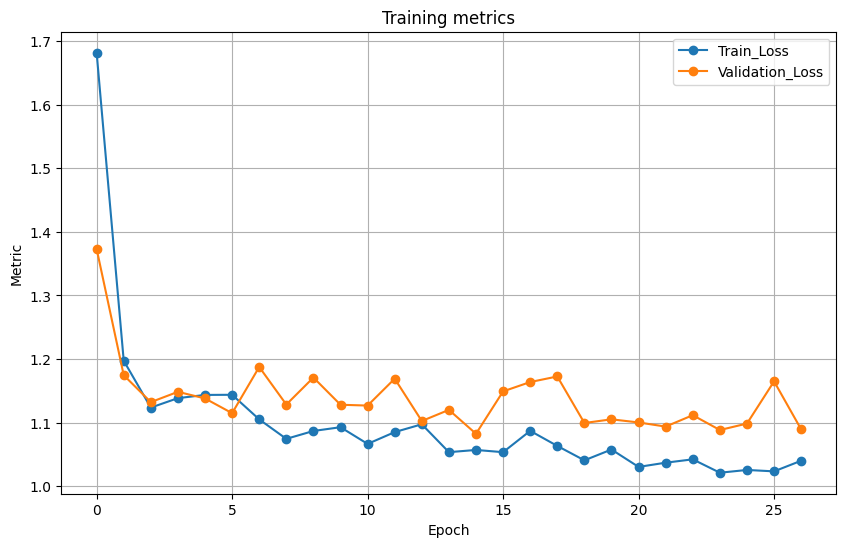

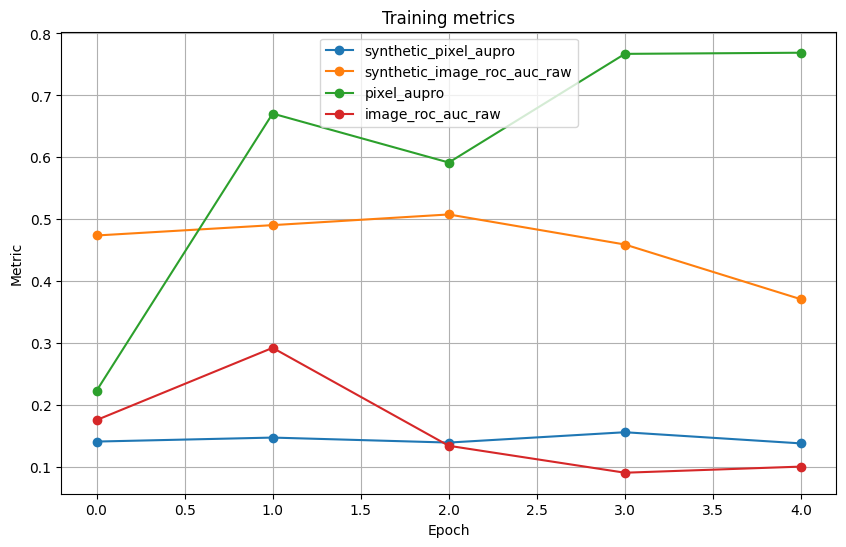

In [16]:
model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True
    )
model = model.to(device)

# Fixed synthetic reference datasets are created once and then reused.
# They cache SSN synthetic masks/labels.
synthetic_val_reference_dataset = create_synthetic_mask_reference_dataset(
    model,
    synthetic_segmentation_val_dataset,
    batch_size=10,
    device=device,
    seed=synthetic_eval_seed,
    desc="Create Synthetic Val Reference",
)
synthetic_test_reference_dataset = create_synthetic_mask_reference_dataset(
    model,
    synthetic_segmentation_test_dataset,
    batch_size=10,
    device=device,
    seed=synthetic_eval_seed + 100,
    desc="Create Synthetic Test Reference",
)

trained_model = train_ssn_with_validation(
    model=model,
    train_dataset=train_dataset,
    validation_dataset=synthetic_val_reference_dataset,
    synthetic_segmentation_dataset=synthetic_val_reference_dataset,
    synthetic_classification_dataset=synthetic_val_reference_dataset,
    real_segmentation_dataset=real_segmentation_val_dataset,
    real_classification_dataset=real_classification_val_dataset,
    num_epochs=70,
    learning_rate=1e-4,
    weight_decay=1e-5,
    device=device,
    log_interval=5,
    log_dir=log_dir,
    batch_size=10,
    resume_from_checkpoint=False,
    freeze_extractor=True,
    early_stopping_patience=12,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min",
    synthetic_eval_seed=synthetic_eval_seed,
)

# Тестирование лучшей обученной модели


In [17]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")


cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [18]:
# Load the trained model from the selected try_N folder.
best_model_path = os.path.join(log_dir, "trained_model.pth")
best_trained_model = torch.load(best_model_path, map_location=device, weights_only=False)
best_trained_model.to(device)
best_trained_model.eval()

test_metrics = {}

# Fully unsupervised/proxy test metrics: generated from held-out normal images.
test_metrics.update(
    evaluate_synthetic_reference(
        best_trained_model,
        synthetic_test_reference_dataset,
        synthetic_test_reference_dataset,
        batch_size=10,
        device=device,
        seed=synthetic_eval_seed + 100,
        include_extra_metrics=True,
    )
)

# Real labeled reference metrics: use only when labels/masks exist and comparison is enabled.
test_metrics.update(
    evaluate_real_segmentation(
        best_trained_model,
        real_segmentation_test_dataset,
        device=device,
        include_per_class=True,
    )
)
test_metrics.update(
    evaluate_real_classification(
        best_trained_model,
        real_classification_test_dataset,
        device=device,
        include_per_class=True,
    )
)

with open(os.path.join(log_dir, "test_metrics.txt"), "w") as f:
    for metric_name, metric_value in test_metrics.items():
        f.write(f"{metric_name}: {metric_value}\n")

comparison_rows = [
    ("segmentation", "synthetic", "synthetic_pixel_aupro", test_metrics.get("synthetic_pixel_aupro")),
    ("segmentation", "synthetic", "synthetic_pixel_roc_auc", test_metrics.get("synthetic_pixel_roc_auc")),
    ("segmentation", "synthetic", "synthetic_pixel_ap", test_metrics.get("synthetic_pixel_ap")),
    ("segmentation", "real", "pixel_aupro", test_metrics.get("pixel_aupro")),
    ("segmentation", "real", "pixel_roc_auc", test_metrics.get("pixel_roc_auc")),
    ("segmentation", "real", "pixel_ap", test_metrics.get("pixel_ap")),
    ("classification", "synthetic", "synthetic_image_roc_auc_raw", test_metrics.get("synthetic_image_roc_auc_raw")),
    ("classification", "synthetic", "synthetic_image_ap_raw", test_metrics.get("synthetic_image_ap_raw")),
    ("classification", "real", "image_roc_auc_raw", test_metrics.get("image_roc_auc_raw")),
    ("classification", "real", "image_ap_raw", test_metrics.get("image_ap_raw")),
]
with open(os.path.join(log_dir, "test_metric_comparison.csv"), "w") as f:
    f.write("task,source,metric,value\n")
    for task, source, metric_name, value in comparison_rows:
        f.write(f"{task},{source},{metric_name},{value}\n")

visualization_dir = os.path.join(log_dir, "test_visualizations")
save_validation_visualizations(
    best_trained_model,
    real_segmentation_test_dataset,
    os.path.join(visualization_dir, "real"),
    device=device,
)
save_synthetic_visualizations(
    best_trained_model,
    synthetic_test_reference_dataset,
    os.path.join(visualization_dir, "synthetic"),
    device=device,
    batch_size=4,
    max_examples=8,
    seed=synthetic_eval_seed + 100,
)

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value}")

synthetic_pixel_aupro: 0.1300562173128128
synthetic_image_roc_auc_raw: 0.4790673025967144
synthetic_pixel_roc_auc: 0.5212989899219571
synthetic_pixel_ap: 0.18604174351841457
synthetic_image_ap_raw: 0.6340665144769907
pixel_aupro: 0.6898735165596008
pixel_roc_auc: 0.9046121998924651
pixel_ap: 0.6388667894103514
pixel_aupro_bent: 0.7006979584693909
pixel_aupro_color: 0.7613831758499146
pixel_aupro_flip: 0.5873937010765076
pixel_aupro_scratch: 0.6819212436676025
image_roc_auc_raw: 0.172147001934236
image_ap_raw: 0.6875897103718542
image_roc_auc_raw_bent: 0.22377622377622378
image_roc_auc_raw_color: 0.3801652892561984
image_roc_auc_raw_flip: 0.0
image_roc_auc_raw_scratch: 0.08333333333333334
